# Experiment Analysis

Interactive analysis notebook for a single experiment folder under `artifacts/`.

This notebook is comparison-first:
- loads one experiment folder via a top-cell path
- reads `meta/config_*.json` and TensorBoard scalar event files from `tb/`
- compares all variations and phases in the experiment
- adds rule-based diagnostic summaries for timeout drift, reward farming, and PPO strain

Recommended workflow:
1. Set `EXPERIMENT_DIR` in the next cell
2. Run all cells top-to-bottom
3. Read overview and comparison tables first
4. Use the overlay plots and drilldown section to inspect any flagged runs


In [88]:
from __future__ import annotations

import json
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
try:
    from IPython.display import Markdown, display
except Exception:
    def display(obj):
        print(obj)
    def Markdown(text):
        return text
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
plt.style.use("default")

# ------------------------------------------------------------
# User-configurable inputs
# ------------------------------------------------------------
DEFAULT_EXPERIMENT = Path(r"artifacts\baselineGoatTrainingV2")
CANDIDATE_ROOTS = [Path.cwd(), Path.cwd().parent, Path.cwd() / ".."]
REPO_ROOT = next((p.resolve() for p in CANDIDATE_ROOTS if (p / "artifacts").exists()), Path.cwd().resolve())
EXPERIMENT_DIR = (REPO_ROOT / DEFAULT_EXPERIMENT).resolve() if not DEFAULT_EXPERIMENT.is_absolute() else DEFAULT_EXPERIMENT
SELECTED_VARIATIONS = None   # Example: ["goat_vs_greedy_tiger_50M"]
SELECTED_PHASES = None       # Example: [1, 2]
SMOOTHING_WINDOW = 5
FIGSIZE = (10, 4)
DRILLDOWN_RUN_ID = None      # Example: "goat_vs_greedy_tiger_50M|20260319_122345|01"

OUTCOME_TAGS = [
    "1.episode_stats (total episodes)/2.goat_win_rate",
    "1.episode_stats (total episodes)/3.tiger_win_rate",
    "1.episode_stats (total episodes)/4.max_timeout_rate",
    "1.episode_stats (total episodes)/5.repeat_timeout_rate",
    "2.window_stats (per 1000 eps)/2.goat_win_rate",
    "2.window_stats (per 1000 eps)/3.tiger_win_rate",
    "2.window_stats (per 1000 eps)/4.max_timeout_rate",
    "2.window_stats (per 1000 eps)/5.repeat_timeout_rate",
]

ROLLOUT_TAGS = [
    "rollout/ep_len_mean",
    "rollout/ep_rew_mean",
]

TRAIN_TAGS = [
    "train/approx_kl",
    "train/clip_fraction",
    "train/clip_range",
    "train/entropy_loss",
    "train/explained_variance",
    "train/learning_rate",
    "train/loss",
    "train/policy_gradient_loss",
    "train/value_loss",
]

REWARD_TAG_PREFIXES = [
    "4.reward_components",
    "5.episode_reward",
]

RUN_DIR_RE = re.compile(r"^(?P<variation_slug>.+)_(?P<run_stamp>\d{8}_\d{6})_phase_(?P<phase_index>\d+)$")


In [89]:
# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def parse_run_dir_name(name: str) -> dict:
    match = RUN_DIR_RE.match(name)
    if not match:
        return {
            "tb_run_dir": name,
            "variation_slug": name,
            "run_stamp": None,
            "phase_index": None,
        }
    data = match.groupdict()
    return {
        "tb_run_dir": name,
        "variation_slug": data["variation_slug"],
        "run_stamp": data["run_stamp"],
        "phase_index": int(data["phase_index"]),
    }


def build_run_id(variation_slug: str, run_stamp: str | None, phase_index: int | None) -> str:
    phase_part = f"{int(phase_index):02d}" if phase_index is not None and not pd.isna(phase_index) else "NA"
    return f"{variation_slug}|{run_stamp or 'unknown'}|{phase_part}"


def build_run_label(row: pd.Series) -> str:
    variation = row.get("variation_name") or row.get("variation_slug") or "unknown_variation"
    phase_index = row.get("phase_index")
    if pd.isna(phase_index):
        return str(variation)
    return f"{variation} | phase {int(phase_index):02d}"


def collect_artifact_inventory(exp_dir: Path) -> pd.DataFrame:
    rows = []
    for subdir in ["meta", "tb", "models", "checkpoints", "eval", "logs"]:
        path = exp_dir / subdir
        exists = path.exists()
        file_count = sum(1 for p in path.rglob("*") if p.is_file()) if exists else 0
        dir_count = sum(1 for p in path.rglob("*") if p.is_dir()) if exists else 0
        rows.append({
            "artifact_group": subdir,
            "exists": exists,
            "file_count": file_count,
            "dir_count": dir_count,
            "path": str(path),
        })
    return pd.DataFrame(rows)


def load_meta_rows(exp_dir: Path) -> pd.DataFrame:
    rows = []
    meta_dir = exp_dir / "meta"
    if not meta_dir.exists():
        return pd.DataFrame()

    for config_path in sorted(meta_dir.glob("config_*.json")):
        payload = json.loads(config_path.read_text(encoding="utf-8"))
        phases = payload.get("phases", []) or [{}]
        for idx, phase in enumerate(phases, start=1):
            rows.append({
                "run_id": build_run_id(payload.get("variation_slug"), payload.get("run_stamp"), idx),
                "variation_name": payload.get("variation_name"),
                "variation_slug": payload.get("variation_slug"),
                "run_stamp": payload.get("run_stamp"),
                "phase_index": idx,
                "phase_timesteps": phase.get("timesteps"),
                "phase_opponent_ai": phase.get("opponent_ai", phase.get("tiger_ai")),
                "phase_mix_prob": phase.get("mix_prob"),
                "phase_goat_model_path": phase.get("goat_model_path"),
                "phase_reward_weights": json.dumps(phase.get("reward_weights"), sort_keys=True) if phase.get("reward_weights") is not None else None,
                "experiment_name": payload.get("experiment_name"),
                "variation_core": payload.get("variation_core"),
                "algo_tag": payload.get("algo_tag"),
                "env_ver": payload.get("env_ver"),
                "model_ver": payload.get("model_ver"),
                "learner_role": payload.get("learner_role"),
                "num_cpu": payload.get("num_cpu"),
                "device_mode": payload.get("device_mode"),
                "device": payload.get("device"),
                "seed": payload.get("seed"),
                "config_path": str(config_path),
            })
    return pd.DataFrame(rows)


def load_tb_scalars(exp_dir: Path) -> pd.DataFrame:
    rows = []
    tb_dir = exp_dir / "tb"
    if not tb_dir.exists():
        return pd.DataFrame()

    for run_dir in sorted([p for p in tb_dir.iterdir() if p.is_dir()]):
        parsed = parse_run_dir_name(run_dir.name)
        run_id = build_run_id(parsed["variation_slug"], parsed["run_stamp"], parsed["phase_index"])
        try:
            accumulator = EventAccumulator(str(run_dir))
            accumulator.Reload()
        except Exception as exc:
            print(f"[WARN] Failed to load TensorBoard run {run_dir.name}: {exc}")
            continue

        for tag in accumulator.Tags().get("scalars", []):
            try:
                events = accumulator.Scalars(tag)
            except Exception as exc:
                print(f"[WARN] Failed scalar tag {tag} in {run_dir.name}: {exc}")
                continue
            for event in events:
                rows.append({
                    "run_id": run_id,
                    "tb_run_dir": run_dir.name,
                    "variation_slug": parsed["variation_slug"],
                    "run_stamp": parsed["run_stamp"],
                    "phase_index": parsed["phase_index"],
                    "tag": tag,
                    "step": event.step,
                    "value": event.value,
                    "wall_time": event.wall_time,
                })
    return pd.DataFrame(rows)


def apply_filters(run_index: pd.DataFrame, scalars_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    filtered = run_index.copy()
    if SELECTED_VARIATIONS:
        allowed = set(SELECTED_VARIATIONS)
        filtered = filtered[
            filtered["variation_name"].isin(allowed) | filtered["variation_slug"].isin(allowed)
        ]
    if SELECTED_PHASES:
        filtered = filtered[filtered["phase_index"].isin(SELECTED_PHASES)]
    allowed_run_ids = set(filtered["run_id"].dropna().tolist())
    if not scalars_df.empty and allowed_run_ids:
        scalars_df = scalars_df[scalars_df["run_id"].isin(allowed_run_ids)].copy()
    return filtered.reset_index(drop=True), scalars_df.reset_index(drop=True)


def build_run_index(meta_df: pd.DataFrame, scalars_df: pd.DataFrame) -> pd.DataFrame:
    tb_run_info = pd.DataFrame()
    if not scalars_df.empty:
        tb_run_info = scalars_df[["run_id", "tb_run_dir", "variation_slug", "run_stamp", "phase_index"]].drop_duplicates()

    if meta_df.empty and tb_run_info.empty:
        return pd.DataFrame()
    if meta_df.empty:
        run_index = tb_run_info.copy()
    elif tb_run_info.empty:
        run_index = meta_df.copy()
    else:
        run_index = tb_run_info.merge(
            meta_df,
            on=["run_id", "variation_slug", "run_stamp", "phase_index"],
            how="outer",
        )

    if "variation_name" not in run_index.columns:
        run_index["variation_name"] = run_index.get("variation_slug")
    run_index["variation_name"] = run_index["variation_name"].fillna(run_index.get("variation_slug"))
    run_index["run_label"] = run_index.apply(build_run_label, axis=1)
    return run_index.sort_values(["variation_name", "run_stamp", "phase_index"], na_position="last").reset_index(drop=True)


def first_last_stats(scalars_df: pd.DataFrame, tag: str) -> pd.DataFrame:
    subset = scalars_df[scalars_df["tag"] == tag].sort_values(["run_id", "step"])
    if subset.empty:
        return pd.DataFrame(columns=["run_id"])

    first = subset.groupby("run_id").first().reset_index()
    last = subset.groupby("run_id").last().reset_index()
    maxv = subset.groupby("run_id")["value"].max().reset_index().rename(columns={"value": "max_value"})
    stats = first[["run_id", "value", "step"]].rename(columns={"value": "first_value", "step": "first_step"})
    stats = stats.merge(
        last[["run_id", "value", "step"]].rename(columns={"value": "final_value", "step": "final_step"}),
        on="run_id",
        how="outer",
    )
    stats = stats.merge(maxv, on="run_id", how="left")
    stats["delta_value"] = stats["final_value"] - stats["first_value"]
    return stats


def build_comparison_table(run_index: pd.DataFrame, scalars_df: pd.DataFrame) -> pd.DataFrame:
    summary = run_index.copy()
    tag_map = {
        "1.episode_stats (total episodes)/2.goat_win_rate": "total_goat_win_rate",
        "1.episode_stats (total episodes)/3.tiger_win_rate": "total_tiger_win_rate",
        "1.episode_stats (total episodes)/4.max_timeout_rate": "total_max_timeout_rate",
        "1.episode_stats (total episodes)/5.repeat_timeout_rate": "total_repeat_timeout_rate",
        "2.window_stats (per 1000 eps)/2.goat_win_rate": "window_goat_win_rate",
        "2.window_stats (per 1000 eps)/3.tiger_win_rate": "window_tiger_win_rate",
        "2.window_stats (per 1000 eps)/4.max_timeout_rate": "window_max_timeout_rate",
        "2.window_stats (per 1000 eps)/5.repeat_timeout_rate": "window_repeat_timeout_rate",
        "rollout/ep_len_mean": "ep_len_mean",
        "rollout/ep_rew_mean": "ep_rew_mean",
        "train/approx_kl": "approx_kl",
        "train/clip_fraction": "clip_fraction",
        "train/explained_variance": "explained_variance",
        "train/value_loss": "value_loss",
    }
    for tag, prefix in tag_map.items():
        stats = first_last_stats(scalars_df, tag)
        if stats.empty:
            continue
        stats = stats.rename(columns={
            "first_value": f"{prefix}_first",
            "final_value": f"{prefix}_final",
            "delta_value": f"{prefix}_delta",
            "max_value": f"{prefix}_max",
            "final_step": f"{prefix}_final_step",
        })
        keep_cols = ["run_id", f"{prefix}_first", f"{prefix}_final", f"{prefix}_delta", f"{prefix}_max", f"{prefix}_final_step"]
        summary = summary.merge(stats[keep_cols], on="run_id", how="left")
    return summary


def diagnose_run(row: pd.Series) -> str:
    flags = []
    timeout_delta = row.get("window_max_timeout_rate_delta")
    win_delta = row.get("window_goat_win_rate_delta")
    ep_rew_delta = row.get("ep_rew_mean_delta")
    ep_len_delta = row.get("ep_len_mean_delta")
    approx_kl_final = row.get("approx_kl_final")
    clip_fraction_final = row.get("clip_fraction_final")
    value_loss_final = row.get("value_loss_final")
    final_timeout = row.get("window_max_timeout_rate_final")
    final_goat_win = row.get("window_goat_win_rate_final")

    if pd.notna(timeout_delta) and pd.notna(win_delta) and timeout_delta > 0.03 and win_delta <= 0:
        flags.append("timeout drift")
    if pd.notna(ep_rew_delta) and pd.notna(ep_len_delta) and pd.notna(timeout_delta):
        if ep_rew_delta > 1.0 and ep_len_delta > 5.0 and timeout_delta > 0.02:
            flags.append("reward-farming suspicion")
    if pd.notna(final_timeout) and pd.notna(win_delta) and pd.notna(final_goat_win):
        if final_timeout < 0.02 and win_delta > 0.05 and final_goat_win > 0.5:
            flags.append("stable conversion")
    if any(pd.notna(v) for v in [approx_kl_final, clip_fraction_final, value_loss_final]):
        if (pd.notna(approx_kl_final) and approx_kl_final > 0.04) or (pd.notna(clip_fraction_final) and clip_fraction_final > 0.28) or (pd.notna(value_loss_final) and value_loss_final > 4.5):
            flags.append("PPO strain")
    if not flags:
        flags.append("no strong rule-based flag")
    return "; ".join(flags)


def smooth_values(values: pd.Series, window: int) -> pd.Series:
    if window is None or window <= 1:
        return values
    return values.rolling(window=window, min_periods=1).mean()


def plot_tag_grid(scalars_df: pd.DataFrame, run_index: pd.DataFrame, tags: list[str], title: str, smooth_window: int = 1, selected_run_ids: list[str] | None = None, ncols: int = 2):
    available = [tag for tag in tags if tag in set(scalars_df["tag"].unique())]
    if not available:
        display(Markdown(f"**{title}**  \nNo matching scalar tags found."))
        return

    subset = scalars_df[scalars_df["tag"].isin(available)].copy()
    if selected_run_ids is not None:
        subset = subset[subset["run_id"].isin(selected_run_ids)].copy()
    subset = subset.merge(run_index[["run_id", "run_label"]].drop_duplicates(), on="run_id", how="left")

    nrows = math.ceil(len(available) / ncols)
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(FIGSIZE[0] * ncols / 1.5, FIGSIZE[1] * nrows),
        squeeze=False,
    )
    display(Markdown(f"## {title}"))
    for ax, tag in zip(axes.flat, available):
        tag_df = subset[subset["tag"] == tag].sort_values(["run_label", "step"])
        for run_label, group in tag_df.groupby("run_label"):
            ax.plot(group["step"], smooth_values(group["value"], smooth_window), label=run_label)
        ax.set_title(tag)
        ax.set_xlabel("step")
        ax.grid(True, alpha=0.3)
        if tag_df["run_label"].nunique() <= 8:
            ax.legend(fontsize=8)
    for ax in axes.flat[len(available):]:
        ax.axis("off")
    fig.tight_layout()
    plt.show()


def first_present_run_id(run_index: pd.DataFrame) -> str | None:
    if run_index.empty:
        return None
    return run_index.iloc[0]["run_id"]


def plot_artifact_inventory(inventory_df: pd.DataFrame):
    if inventory_df.empty:
        return
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    file_df = inventory_df.sort_values("file_count", ascending=True)
    axes[0].barh(file_df["artifact_group"], file_df["file_count"], color="#4C78A8")
    axes[0].set_title("Artifact File Counts")
    axes[0].set_xlabel("files")
    axes[0].grid(True, axis="x", alpha=0.3)
    dir_df = inventory_df.sort_values("dir_count", ascending=True)
    axes[1].barh(dir_df["artifact_group"], dir_df["dir_count"], color="#F58518")
    axes[1].set_title("Artifact Directory Counts")
    axes[1].set_xlabel("directories")
    axes[1].grid(True, axis="x", alpha=0.3)
    fig.tight_layout()
    plt.show()


def plot_comparison_bars(df: pd.DataFrame, metrics: list[tuple[str, str]], title: str, horizontal: bool = False):
    available = [(col, label) for col, label in metrics if col in df.columns]
    if df.empty or not available:
        display(Markdown(f"**{title}**  \nNo metrics available for bar chart."))
        return
    chart_df = df.copy()
    if "run_label" not in chart_df.columns:
        chart_df["run_label"] = chart_df.apply(build_run_label, axis=1)
    nrows = math.ceil(len(available) / 2)
    fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(14, 4 * nrows), squeeze=False)
    display(Markdown(f"## {title}"))
    for ax, (col, label) in zip(axes.flat, available):
        plot_df = chart_df[["run_label", col]].dropna().sort_values(col, ascending=horizontal)
        if horizontal:
            ax.barh(plot_df["run_label"], plot_df[col], color="#4C78A8")
            ax.set_ylabel("run")
            ax.grid(True, axis="x", alpha=0.3)
        else:
            ax.bar(plot_df["run_label"], plot_df[col], color="#4C78A8")
            ax.tick_params(axis="x", rotation=35)
            ax.grid(True, axis="y", alpha=0.3)
        ax.set_title(label)
        ax.set_xlabel("run")
        ax.set_ylabel(col)
    for ax in axes.flat[len(available):]:
        ax.axis("off")
    fig.tight_layout()
    plt.show()


def plot_behavior_scatter(df: pd.DataFrame):
    required = ["ep_len_mean_final", "ep_rew_mean_final", "window_max_timeout_rate_final"]
    if df.empty or any(col not in df.columns for col in required):
        display(Markdown("**Behavior Scatter**  \nRequired columns not available."))
        return
    chart_df = df.copy()
    if "run_label" not in chart_df.columns:
        chart_df["run_label"] = chart_df.apply(build_run_label, axis=1)
    size_col = chart_df["window_goat_win_rate_final"] if "window_goat_win_rate_final" in chart_df.columns else pd.Series([0.5] * len(chart_df))
    sizes = 250 + size_col.fillna(0).astype(float) * 600
    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(
        chart_df["ep_len_mean_final"],
        chart_df["ep_rew_mean_final"],
        s=sizes,
        c=chart_df["window_max_timeout_rate_final"],
        cmap="viridis",
        alpha=0.8,
        edgecolors="black",
    )
    for _, row in chart_df.iterrows():
        ax.annotate(row["run_label"], (row["ep_len_mean_final"], row["ep_rew_mean_final"]), xytext=(5, 5), textcoords="offset points", fontsize=8)
    ax.set_title("Behavior Scatter: Reward vs Episode Length")
    ax.set_xlabel("final ep_len_mean")
    ax.set_ylabel("final ep_rew_mean")
    ax.grid(True, alpha=0.3)
    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label("final max_timeout_rate")
    plt.show()


In [90]:
# ------------------------------------------------------------
# Load experiment data
# ------------------------------------------------------------
if not EXPERIMENT_DIR.exists():
    raise FileNotFoundError(f"Experiment directory does not exist: {EXPERIMENT_DIR}")

inventory_df = collect_artifact_inventory(EXPERIMENT_DIR)
meta_df = load_meta_rows(EXPERIMENT_DIR)
scalars_df = load_tb_scalars(EXPERIMENT_DIR)
run_index = build_run_index(meta_df, scalars_df)
run_index, scalars_df = apply_filters(run_index, scalars_df)
available_tags = sorted(scalars_df["tag"].unique().tolist()) if not scalars_df.empty else []
comparison_df = build_comparison_table(run_index, scalars_df) if not run_index.empty else pd.DataFrame()
if not comparison_df.empty:
    comparison_df["diagnostic_summary"] = comparison_df.apply(diagnose_run, axis=1)

display(Markdown(f"# Loaded Experiment: `{EXPERIMENT_DIR}`"))
display(Markdown(f"Runs discovered: **{len(run_index)}**  \nScalar tags discovered: **{len(available_tags)}**"))


# Loaded Experiment: `C:\Users\DaFalcons\Documents\TNG_Falcon\artifacts\baselineGoatTrainingV2`

Runs discovered: **2**  
Scalar tags discovered: **30**

In [91]:
# ------------------------------------------------------------
# Experiment overview
# ------------------------------------------------------------
display(Markdown("## Artifact Inventory"))
display(inventory_df)

display(Markdown("## Variation / Phase Inventory"))
if run_index.empty:
    display(Markdown("No runs discovered for this experiment."))
else:
    cols = [
        "variation_name", "variation_slug", "run_stamp", "phase_index", "variation_core",
        "phase_opponent_ai", "phase_mix_prob", "learner_role", "num_cpu", "device_mode",
        "tb_run_dir", "config_path",
    ]
    cols = [c for c in cols if c in run_index.columns]
    display(run_index[cols].sort_values(["variation_name", "run_stamp", "phase_index"], na_position="last"))

display(Markdown("## Available Scalar Tags"))
display(pd.DataFrame({"tag": available_tags}))


## Artifact Inventory

,artifact_group,exists,file_count,dir_count,path
0,meta,True,6,0,C:\Users\DaFalcons\Documents\TNG_Falcon\artifa...
1,tb,True,2,2,C:\Users\DaFalcons\Documents\TNG_Falcon\artifa...
2,models,True,2,0,C:\Users\DaFalcons\Documents\TNG_Falcon\artifa...
3,checkpoints,True,17,2,C:\Users\DaFalcons\Documents\TNG_Falcon\artifa...
4,eval,True,0,0,C:\Users\DaFalcons\Documents\TNG_Falcon\artifa...
5,logs,True,0,0,C:\Users\DaFalcons\Documents\TNG_Falcon\artifa...


## Variation / Phase Inventory

,variation_name,variation_slug,run_stamp,phase_index,variation_core,phase_opponent_ai,phase_mix_prob,learner_role,num_cpu,device_mode,tb_run_dir,config_path
0,goat_vs_greedy_tiger_50M,goat_vs_greedy_tiger_50M,20260319_122345,1,GvNT,tiger_greedy,None,goat,16,gpu,goat_vs_greedy_tiger_50M_20260319_122345_phase_01,C:\Users\DaFalcons\Documents\TNG_Falcon\artifa...
1,goat_vs_smart_tiger_50M,goat_vs_smart_tiger_50M,20260319_195056,1,GvST,tiger_smart,None,goat,16,gpu,goat_vs_smart_tiger_50M_20260319_195056_phase_01,C:\Users\DaFalcons\Documents\TNG_Falcon\artifa...


## Available Scalar Tags

,tag
0,1.episode_stats (total episodes)/1.episode_index
1,1.episode_stats (total episodes)/2.goat_win_rate
2,1.episode_stats (total episodes)/3.tiger_win_rate
3,1.episode_stats (total episodes)/4.max_timeout...
4,1.episode_stats (total episodes)/5.repeat_time...
5,2.window_stats (per 1000 eps)/1.episodes_tracked
6,2.window_stats (per 1000 eps)/2.goat_win_rate
7,2.window_stats (per 1000 eps)/3.tiger_win_rate
8,2.window_stats (per 1000 eps)/4.max_timeout_rate
9,2.window_stats (per 1000 eps)/5.repeat_timeout...


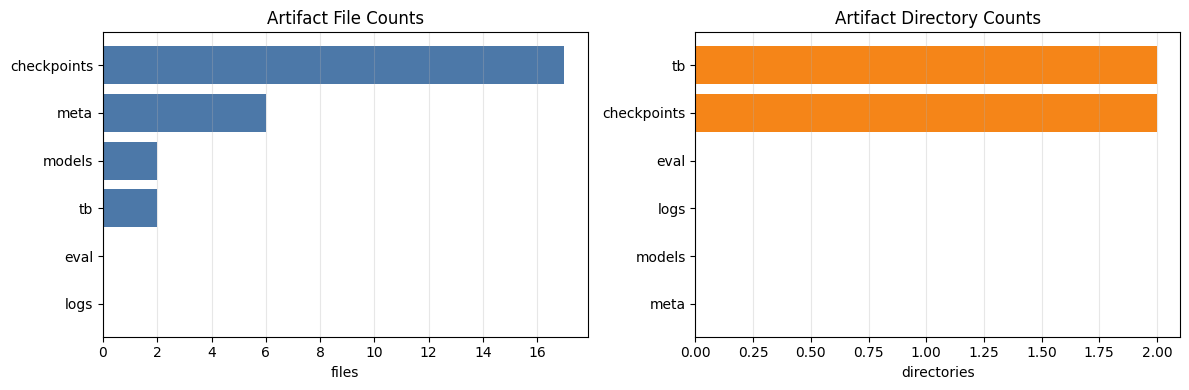

In [92]:
# Artifact inventory charts
plot_artifact_inventory(inventory_df)


In [93]:
# ------------------------------------------------------------
# Variation comparison table
# ------------------------------------------------------------
display(Markdown("## Comparison Table"))
if comparison_df.empty:
    display(Markdown("No comparison data available."))
else:
    preferred_cols = [
        "variation_name", "phase_index", "variation_core", "phase_opponent_ai", "phase_mix_prob",
        "window_goat_win_rate_final", "window_tiger_win_rate_final", "window_max_timeout_rate_final", "window_repeat_timeout_rate_final",
        "window_goat_win_rate_delta", "window_max_timeout_rate_delta",
        "ep_len_mean_final", "ep_len_mean_delta", "ep_rew_mean_final", "ep_rew_mean_delta",
        "approx_kl_final", "clip_fraction_final", "explained_variance_final", "value_loss_final",
        "diagnostic_summary",
    ]
    preferred_cols = [c for c in preferred_cols if c in comparison_df.columns]
    display(comparison_df[preferred_cols].sort_values(["variation_name", "phase_index"], na_position="last"))


## Comparison Table

,variation_name,phase_index,variation_core,phase_opponent_ai,phase_mix_prob,window_goat_win_rate_final,window_tiger_win_rate_final,window_max_timeout_rate_final,window_repeat_timeout_rate_final,window_goat_win_rate_delta,window_max_timeout_rate_delta,ep_len_mean_final,ep_len_mean_delta,ep_rew_mean_final,ep_rew_mean_delta,approx_kl_final,clip_fraction_final,explained_variance_final,value_loss_final,diagnostic_summary
0,goat_vs_greedy_tiger_50M,1,GvNT,tiger_greedy,None,0.641,0.072,0.197,0.090,0.641,0.197,71.139999,56.509999,12.020014,16.434294,0.045855,0.247975,0.608608,5.048717,reward-farming suspicion; PPO strain
1,goat_vs_smart_tiger_50M,1,GvST,tiger_smart,None,0.743,0.249,0.000,0.008,0.743,0.000,21.320000,6.860000,1.481772,7.221590,0.040563,0.220573,0.535311,3.292341,stable conversion; PPO strain


## Final Outcome Metrics (Bar Charts)

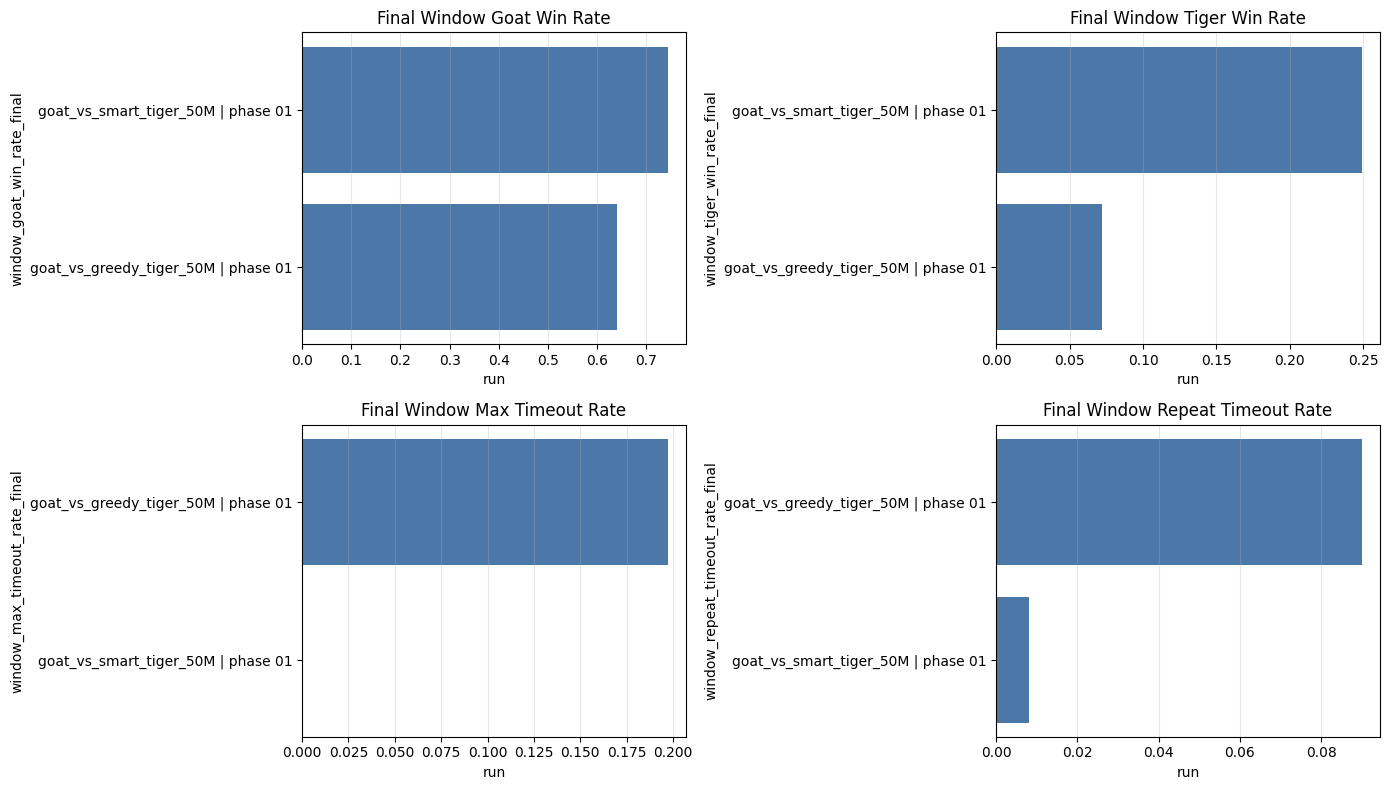

## Final Rollout / PPO Summary (Bar Charts)

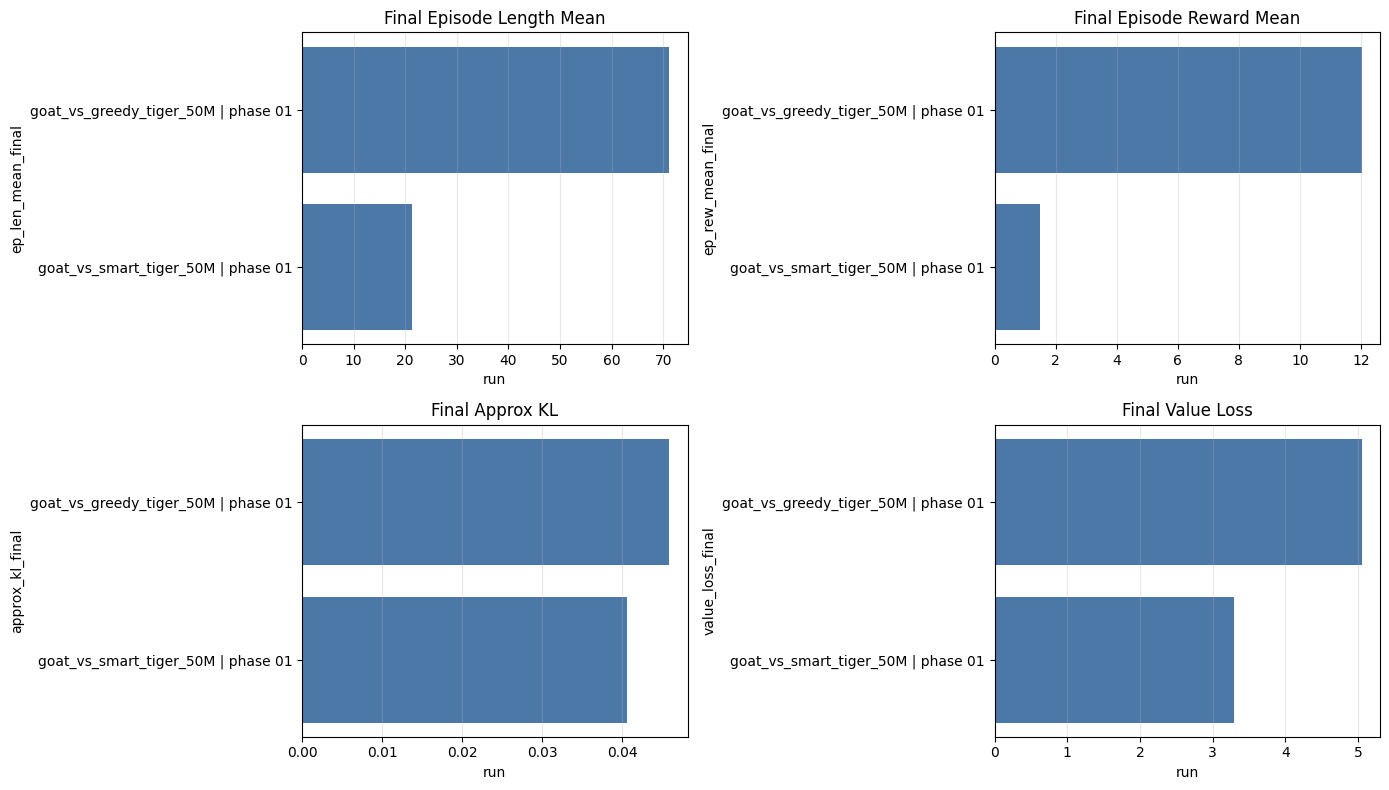

In [94]:
# Final outcome / rollout bar charts
if comparison_df.empty:
    display(Markdown("No comparison charts available."))
else:
    plot_comparison_bars(
        comparison_df,
        [
            ("window_goat_win_rate_final", "Final Window Goat Win Rate"),
            ("window_tiger_win_rate_final", "Final Window Tiger Win Rate"),
            ("window_max_timeout_rate_final", "Final Window Max Timeout Rate"),
            ("window_repeat_timeout_rate_final", "Final Window Repeat Timeout Rate"),
        ],
        title="Final Outcome Metrics (Bar Charts)",
        horizontal=True,
    )
    plot_comparison_bars(
        comparison_df,
        [
            ("ep_len_mean_final", "Final Episode Length Mean"),
            ("ep_rew_mean_final", "Final Episode Reward Mean"),
            ("approx_kl_final", "Final Approx KL"),
            ("value_loss_final", "Final Value Loss"),
        ],
        title="Final Rollout / PPO Summary (Bar Charts)",
        horizontal=True,
    )


## Metric Change from First to Final Logged Value

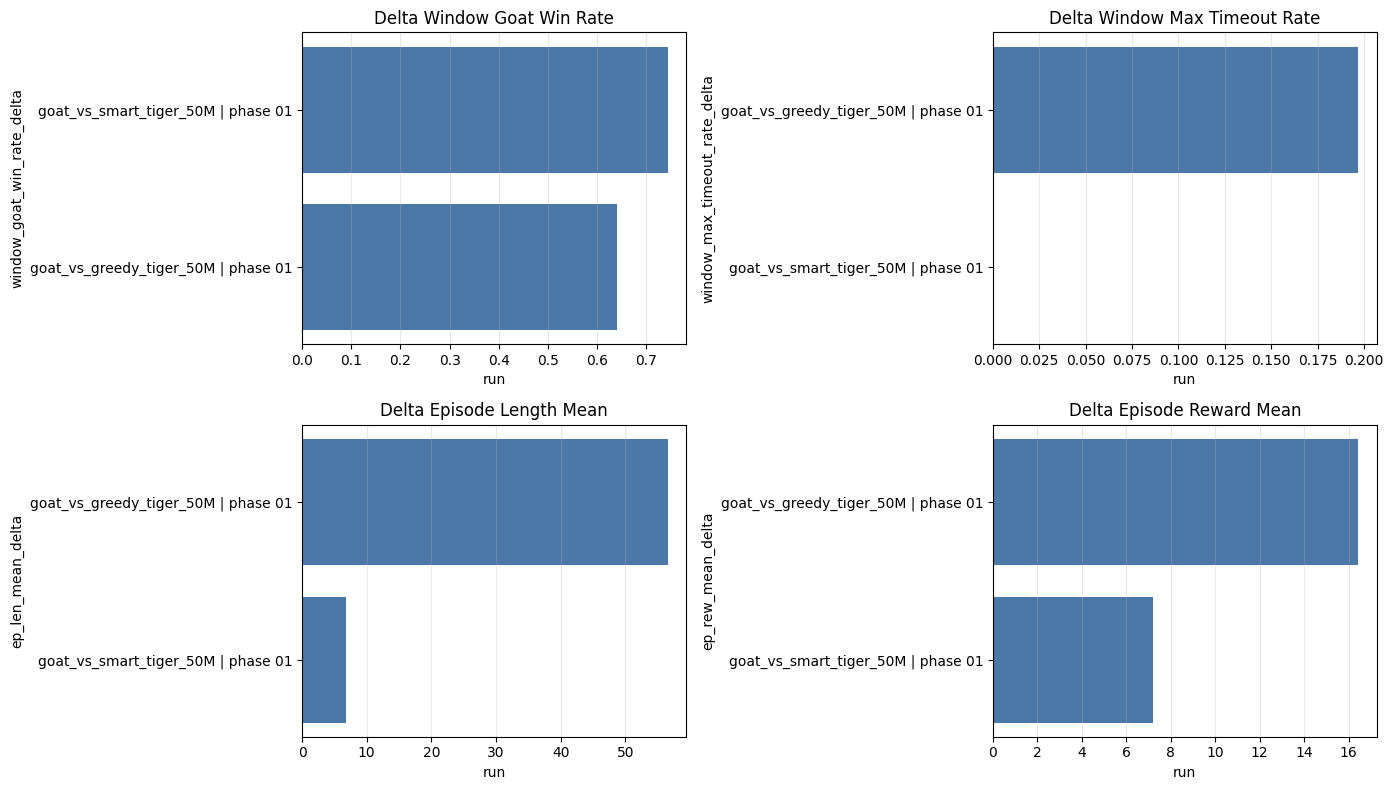

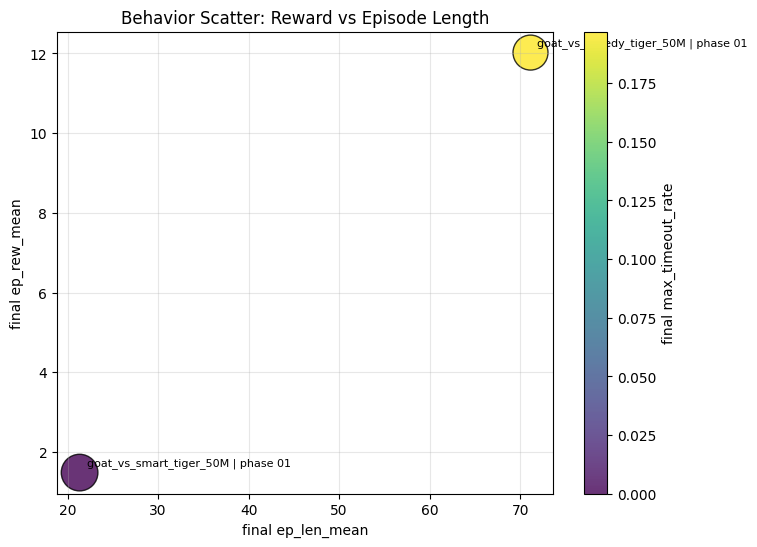

In [95]:
# Delta bar charts and behavior scatter
if comparison_df.empty:
    display(Markdown("No delta or scatter charts available."))
else:
    plot_comparison_bars(
        comparison_df,
        [
            ("window_goat_win_rate_delta", "Delta Window Goat Win Rate"),
            ("window_max_timeout_rate_delta", "Delta Window Max Timeout Rate"),
            ("ep_len_mean_delta", "Delta Episode Length Mean"),
            ("ep_rew_mean_delta", "Delta Episode Reward Mean"),
        ],
        title="Metric Change from First to Final Logged Value",
        horizontal=True,
    )
    plot_behavior_scatter(comparison_df)


In [96]:
# ------------------------------------------------------------
# Diagnostic summary
# ------------------------------------------------------------
display(Markdown("## Diagnostic Summary"))
if comparison_df.empty:
    display(Markdown("No diagnostics available."))
else:
    diagnostic_cols = [
        "variation_name", "phase_index", "window_goat_win_rate_final", "window_max_timeout_rate_final",
        "ep_len_mean_final", "ep_rew_mean_final", "approx_kl_final", "clip_fraction_final", "value_loss_final",
        "diagnostic_summary",
    ]
    diagnostic_cols = [c for c in diagnostic_cols if c in comparison_df.columns]
    display(comparison_df[diagnostic_cols].sort_values(["variation_name", "phase_index"], na_position="last"))

    flagged = comparison_df[["variation_name", "phase_index", "diagnostic_summary"]].copy()
    for _, row in flagged.iterrows():
        display(Markdown(f"- **{row['variation_name']} phase {int(row['phase_index']):02d}**: {row['diagnostic_summary']}"))


## Diagnostic Summary

,variation_name,phase_index,window_goat_win_rate_final,window_max_timeout_rate_final,ep_len_mean_final,ep_rew_mean_final,approx_kl_final,clip_fraction_final,value_loss_final,diagnostic_summary
0,goat_vs_greedy_tiger_50M,1,0.641,0.197,71.139999,12.020014,0.045855,0.247975,5.048717,reward-farming suspicion; PPO strain
1,goat_vs_smart_tiger_50M,1,0.743,0.000,21.320000,1.481772,0.040563,0.220573,3.292341,stable conversion; PPO strain


- **goat_vs_greedy_tiger_50M phase 01**: reward-farming suspicion; PPO strain

- **goat_vs_smart_tiger_50M phase 01**: stable conversion; PPO strain

## Outcome Metrics

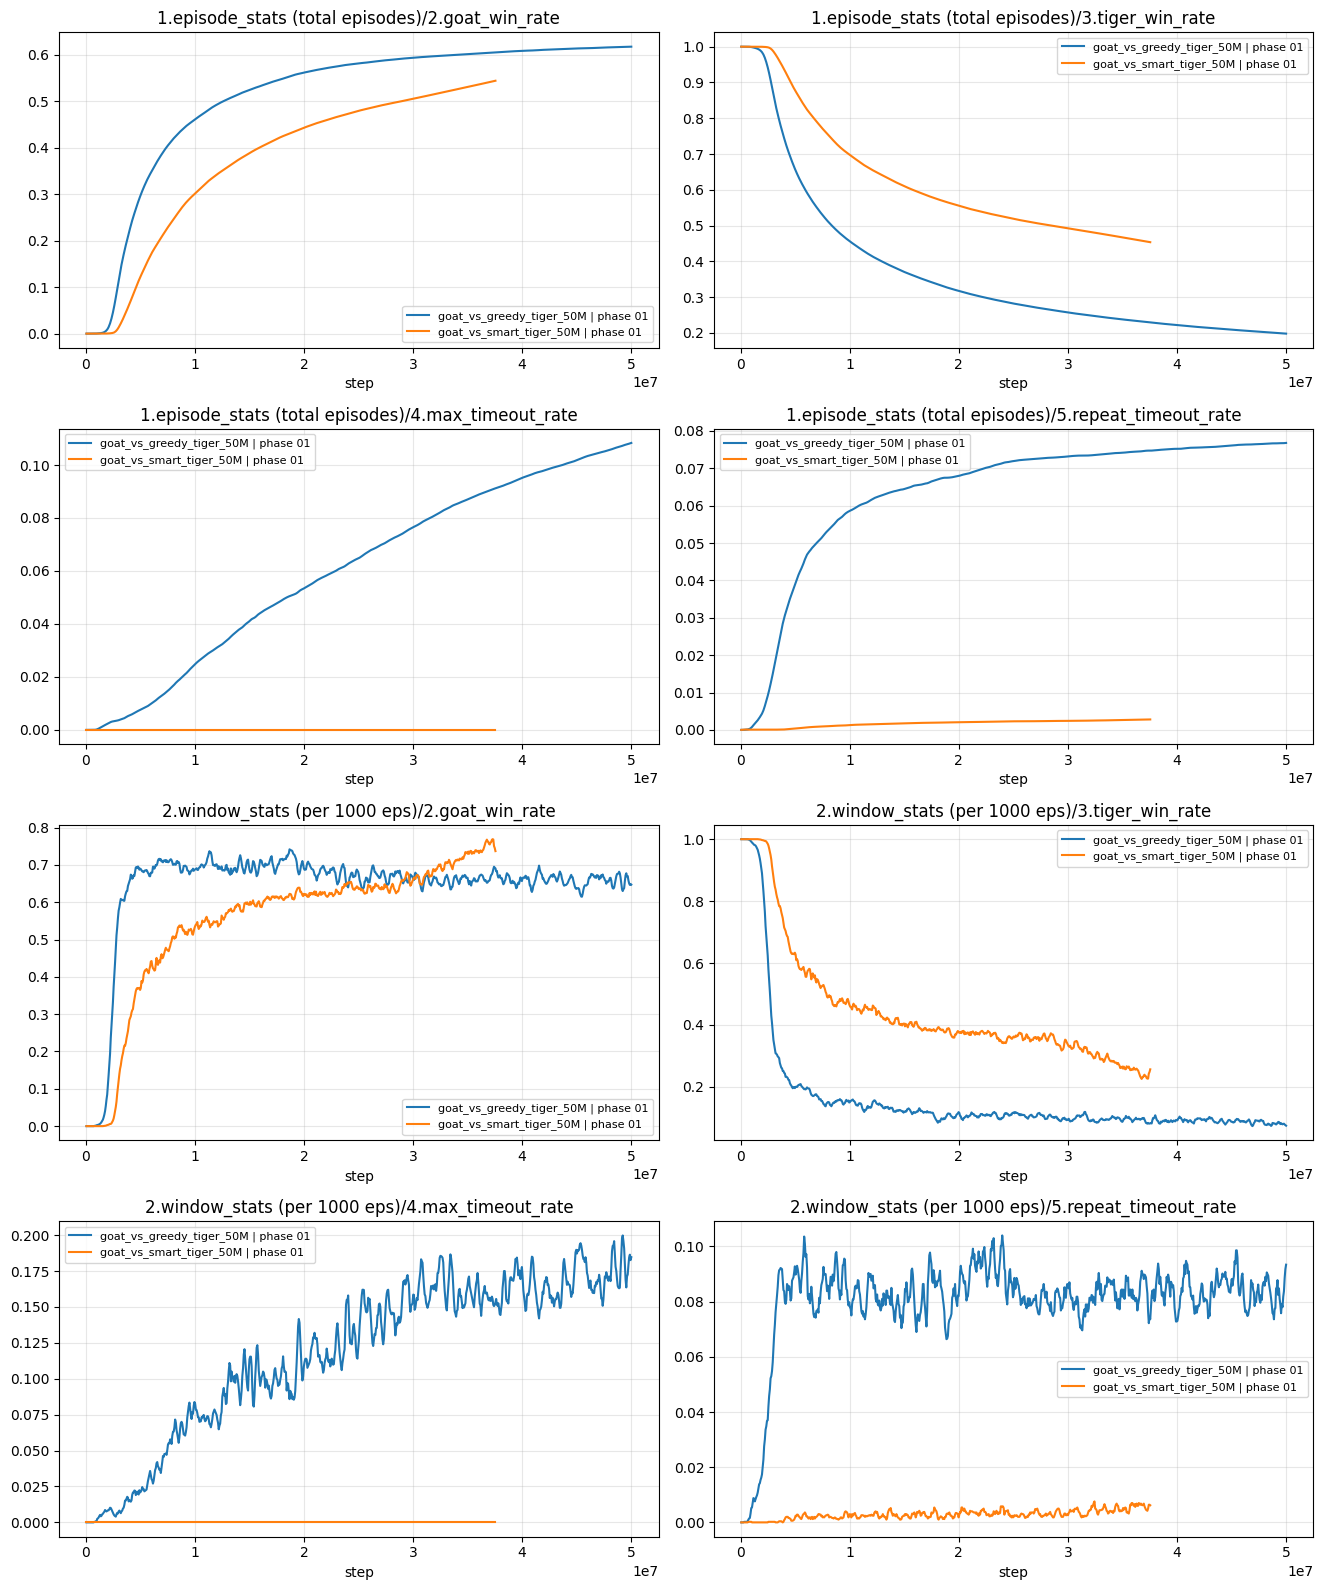

In [97]:
# Outcome overlays
plot_tag_grid(scalars_df, run_index, OUTCOME_TAGS, title="Outcome Metrics", smooth_window=SMOOTHING_WINDOW)


## Rollout Metrics

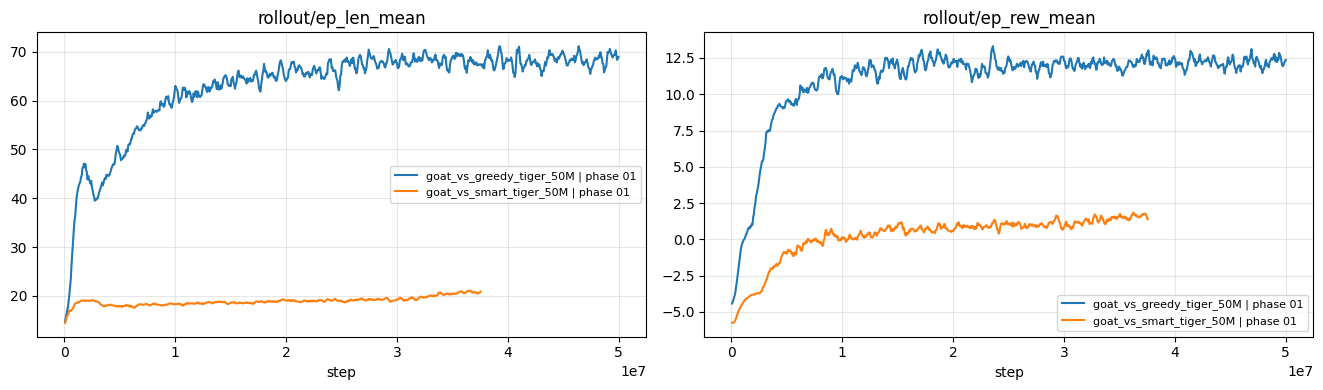

In [98]:
# Rollout overlays
plot_tag_grid(scalars_df, run_index, ROLLOUT_TAGS, title="Rollout Metrics", smooth_window=SMOOTHING_WINDOW)


## PPO Train Metrics

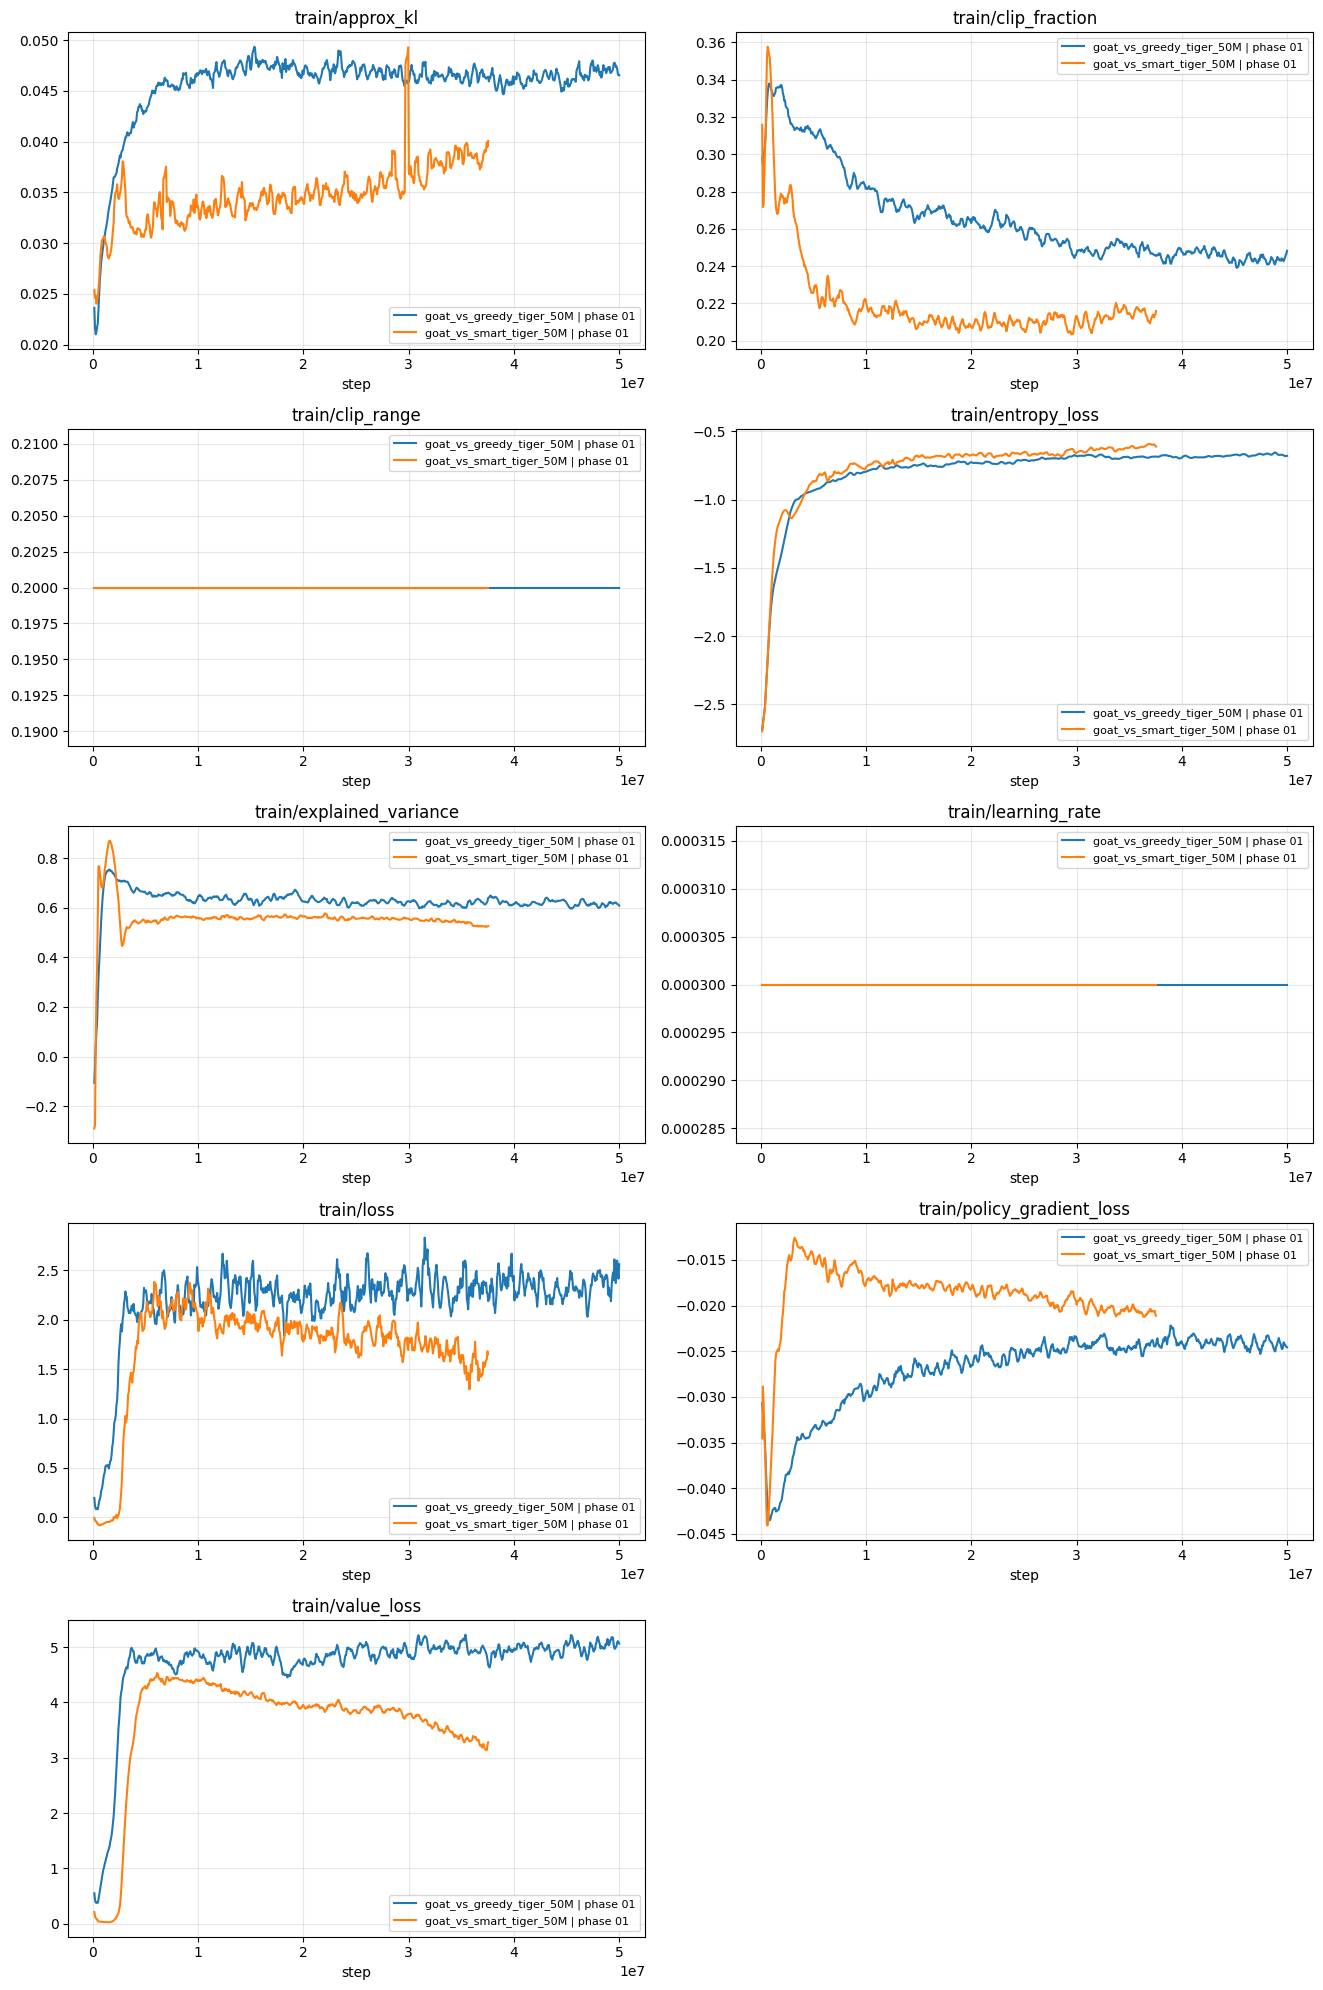

In [99]:
# PPO train overlays
plot_tag_grid(scalars_df, run_index, TRAIN_TAGS, title="PPO Train Metrics", smooth_window=SMOOTHING_WINDOW)


In [100]:
# Reward-component overlays (shown only when present)
reward_tags = [tag for tag in available_tags if any(tag.startswith(prefix) for prefix in REWARD_TAG_PREFIXES)]
plot_tag_grid(scalars_df, run_index, reward_tags, title="Reward Components", smooth_window=SMOOTHING_WINDOW)


**Reward Components**  
No matching scalar tags found.

## Single-Run Drilldown

Selected run: `goat_vs_greedy_tiger_50M|20260319_122345|01`

,0
run_id,goat_vs_greedy_tiger_50M|20260319_122345|01
tb_run_dir,goat_vs_greedy_tiger_50M_20260319_122345_phase_01
variation_slug,goat_vs_greedy_tiger_50M
run_stamp,20260319_122345
phase_index,1
variation_name,goat_vs_greedy_tiger_50M
phase_timesteps,50000000
phase_opponent_ai,tiger_greedy
phase_mix_prob,None
phase_goat_model_path,stable_models\models\Goats\mppo_GvMixT_goat_GT...


## Drilldown: Outcome Metrics

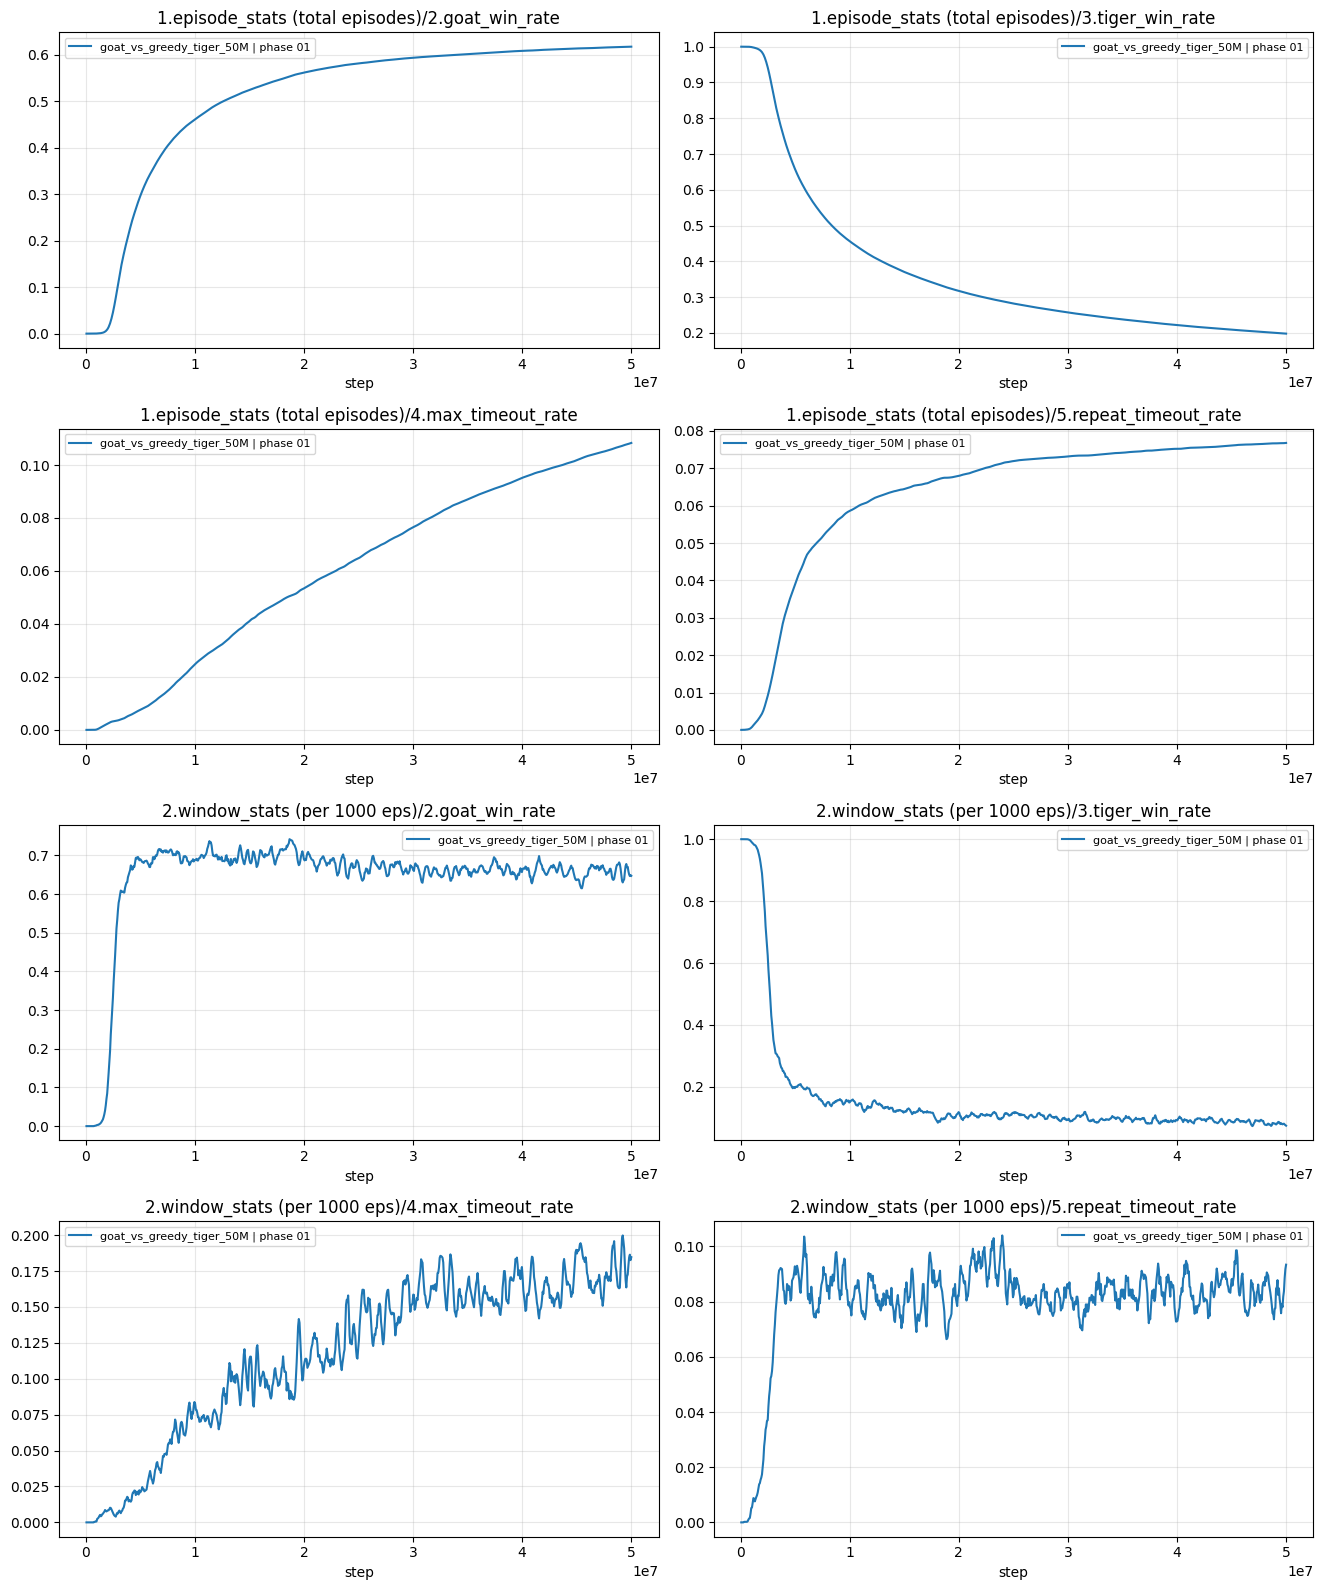

## Drilldown: Rollout Metrics

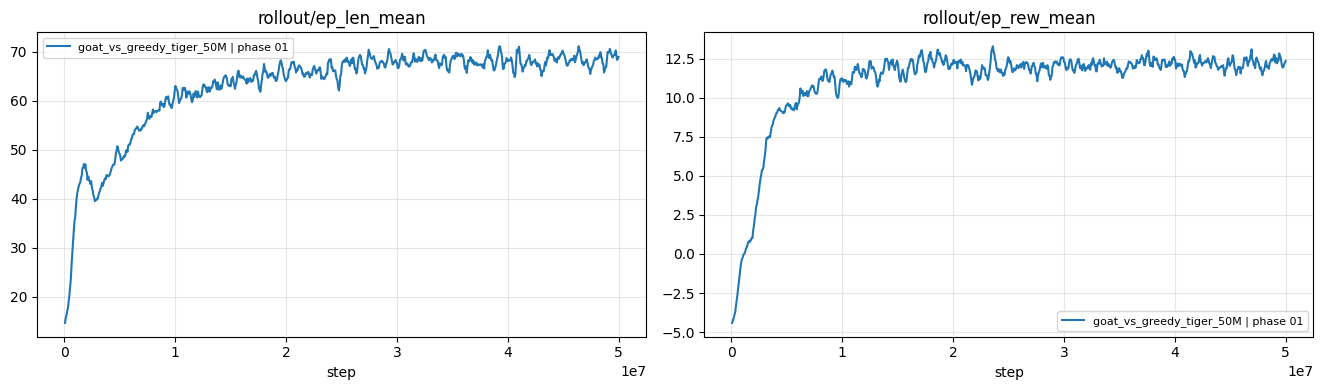

## Drilldown: PPO Train Metrics

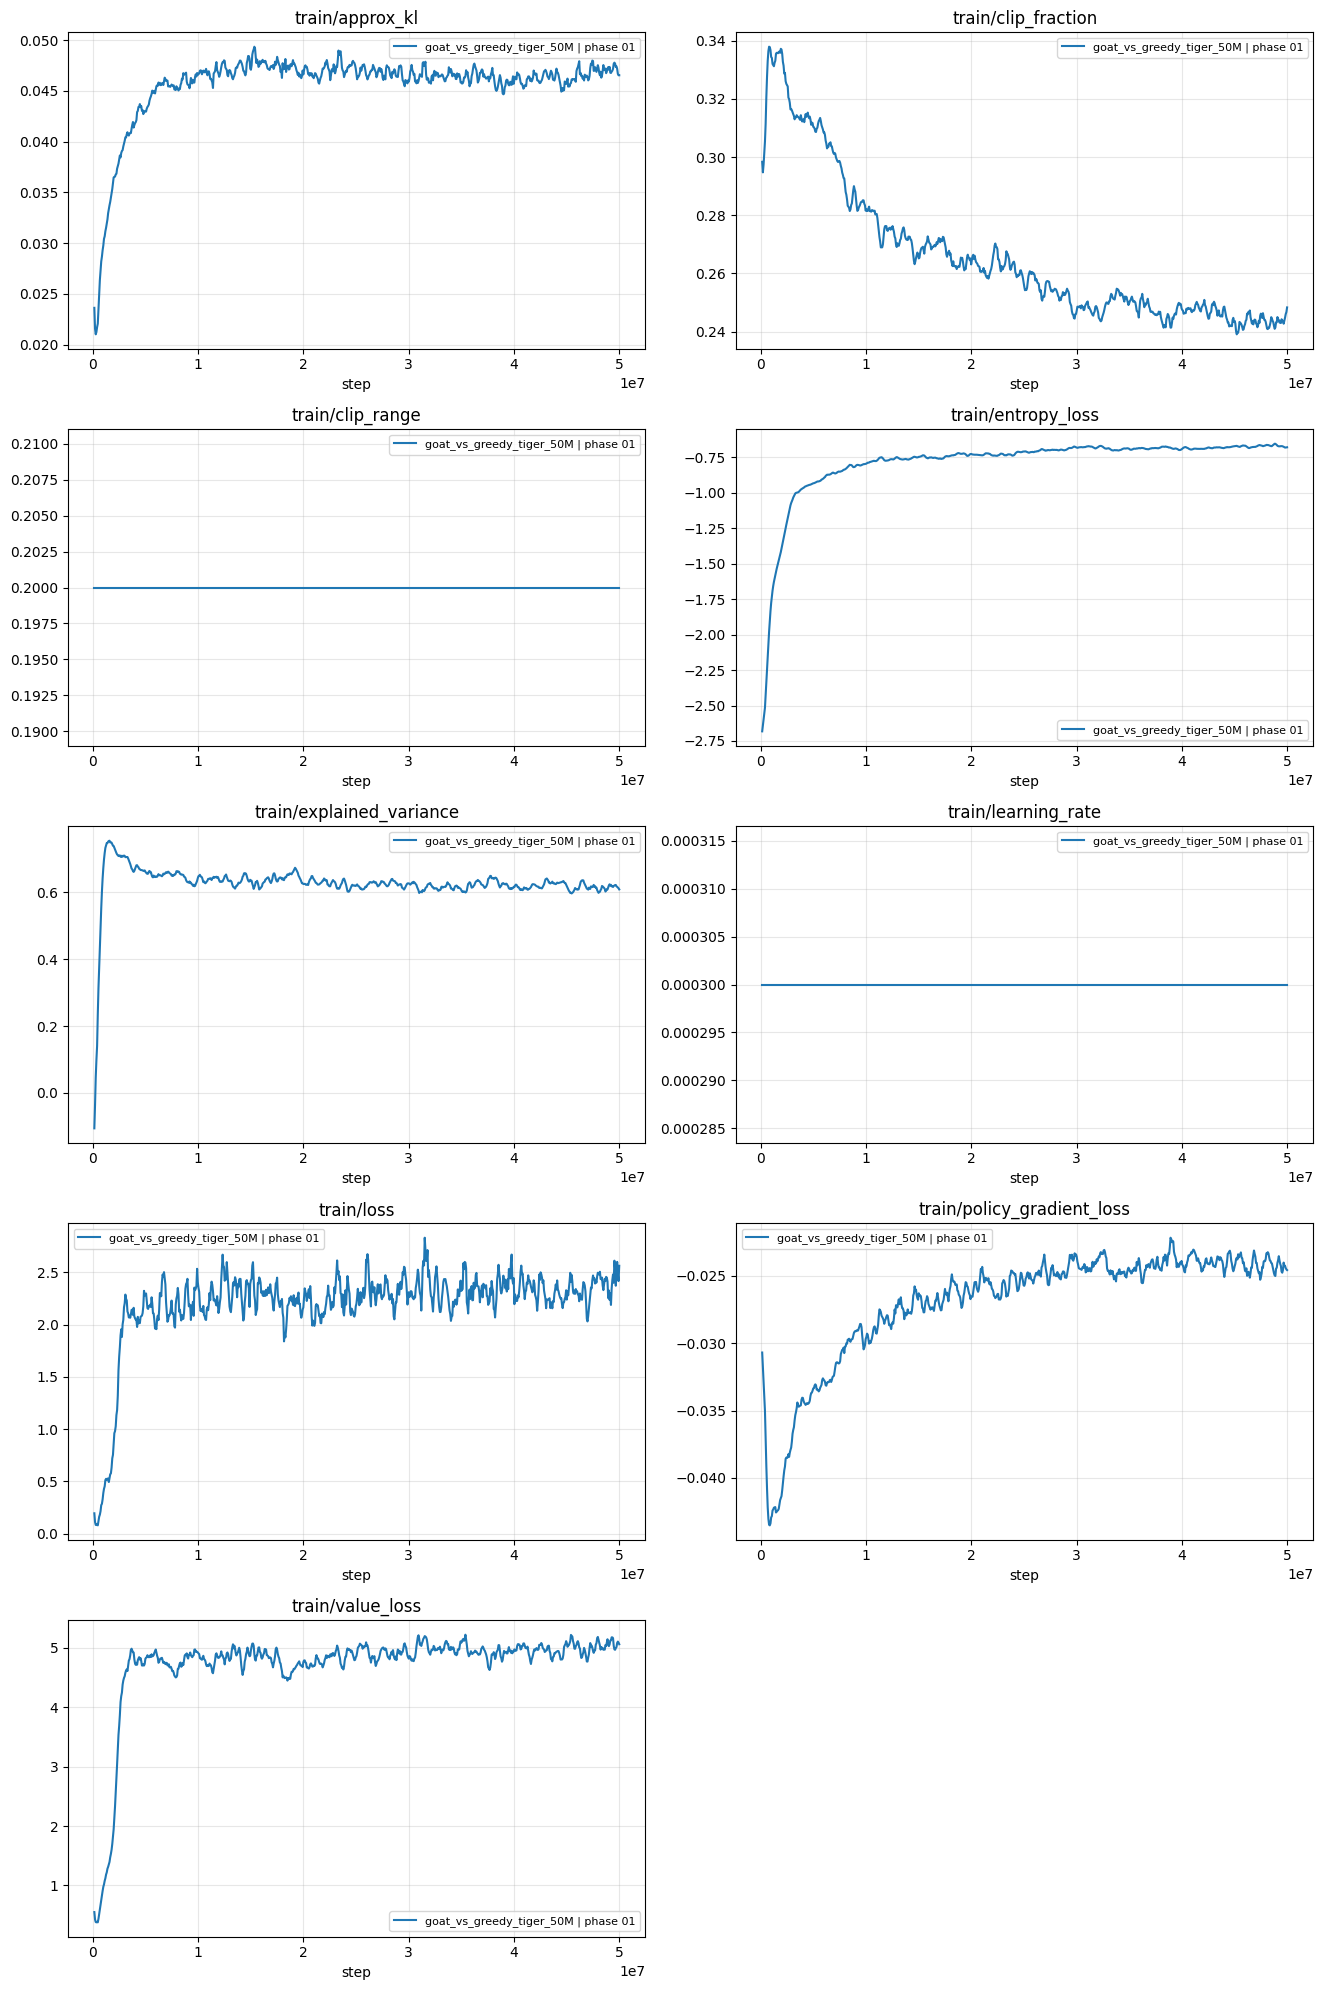

**Drilldown: Reward Components**  
No matching scalar tags found.

In [101]:
# ------------------------------------------------------------
# Single-run drilldown
# ------------------------------------------------------------
display(Markdown("## Single-Run Drilldown"))
selected_run_id = DRILLDOWN_RUN_ID or first_present_run_id(run_index)
if selected_run_id is None:
    display(Markdown("No run available for drilldown."))
else:
    display(Markdown(f"Selected run: `{selected_run_id}`"))
    run_meta = run_index[run_index["run_id"] == selected_run_id]
    if not run_meta.empty:
        display(run_meta.T)
    run_scalars = scalars_df[scalars_df["run_id"] == selected_run_id]
    plot_tag_grid(run_scalars, run_index, OUTCOME_TAGS, title="Drilldown: Outcome Metrics", smooth_window=SMOOTHING_WINDOW, selected_run_ids=[selected_run_id])
    plot_tag_grid(run_scalars, run_index, ROLLOUT_TAGS, title="Drilldown: Rollout Metrics", smooth_window=SMOOTHING_WINDOW, selected_run_ids=[selected_run_id])
    plot_tag_grid(run_scalars, run_index, TRAIN_TAGS, title="Drilldown: PPO Train Metrics", smooth_window=SMOOTHING_WINDOW, selected_run_ids=[selected_run_id])
    run_reward_tags = [tag for tag in run_scalars["tag"].unique().tolist() if any(tag.startswith(prefix) for prefix in REWARD_TAG_PREFIXES)]
    plot_tag_grid(run_scalars, run_index, run_reward_tags, title="Drilldown: Reward Components", smooth_window=SMOOTHING_WINDOW, selected_run_ids=[selected_run_id])
